# 🏥 Projet : Pipeline Complet de Vision Artificielle
## Analyse et Classification d'Images Médicales (Pneumonie vs Normal)

**Filière :** GBM2  
**Module :** Vision Artificielle — Semestre 2  
**Enseignante :** Dr. Imene OUALI  
**Année Universitaire :** 2025-2026

---

## 📋 Structure du Projet
| Partie | Description |
|--------|-------------|
| A | Choix du jeu de données |
| B | Prétraitement |
| C | Segmentation |
| D | Extraction des caractéristiques |
| E | Construction du vecteur de features |
| F | Sélection des descripteurs |
| G | Classification |
| H | Évaluation |

In [19]:
# ============================================================
# IMPORTS GLOBAUX
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

from skimage import filters, morphology, measure, exposure
from skimage.feature import graycomatrix, graycoprops, corner_harris, corner_peaks, ORB
from skimage.color import rgb2gray
from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA

print('✅ Toutes les bibliothèques importées avec succès.')

✅ Toutes les bibliothèques importées avec succès.


---
## PARTIE A — Choix du Jeu de Données

### Dataset choisi : Radiographies Thoraciques (Pneumonie vs Normal)

**Source :** Kaggle — Chest X-Ray Images (Pneumonia)  
**Lien :** https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

**Description :**
- **Classe 0 — NORMAL** : radiographies thoraciques de patients sains
- **Classe 1 — PNEUMONIA** : radiographies montrant des opacités / infiltrats liés à la pneumonie
- **Format :** images JPEG en niveaux de gris ou RGB convertibles
- **Taille utilisée ici :** 60 images (30 par classe) pour faciliter les calculs

**Justification :**  
La pneumonie est une pathologie sérieuse détectable sur radiographies. Les images présentent des différences visuelles claires (opacités, textures) ce qui en fait un problème idéal pour notre pipeline.

In [ ]:
# ============================================================
# CHARGEMENT DU VRAI DATASET KAGGLE
# ============================================================
import cv2, os
import numpy as np

IMG_SIZE = 128


DATA_DIR = r"C:\Users\boual\Downloads\archive (10)\chest_xray\train"

def load_images_from_folder(folder, label, max_images=50):
    images, labels, names = [], [], []
    files = [f for f in os.listdir(folder)
             if f.endswith('.jpeg') or f.endswith('.jpg') or f.endswith('.png')]
    for fname in files[:max_images]:
        path = os.path.join(folder, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img.astype(np.float32) / 255.0)
            labels.append(label)
            names.append(fname)
    return images, labels, names
imgs_n, lbl_n, nam_n = load_images_from_folder(
    os.path.join(DATA_DIR, "NORMAL"),    0, 200)  # 50 → 200

imgs_p, lbl_p, nam_p = load_images_from_folder(
    os.path.join(DATA_DIR, "PNEUMONIA"), 1, 200)  # 50 → 200

all_images = imgs_n + imgs_p
all_labels = lbl_n  + lbl_p
all_names  = nam_n  + nam_p
N = len(imgs_n)

print(f" {len(all_images)} images chargées")
print(f"   - NORMAL    : {len(imgs_n)} images")
print(f"   - PNEUMONIE : {len(imgs_p)} images")

✅ 400 images chargées
   - NORMAL    : 200 images
   - PNEUMONIE : 200 images


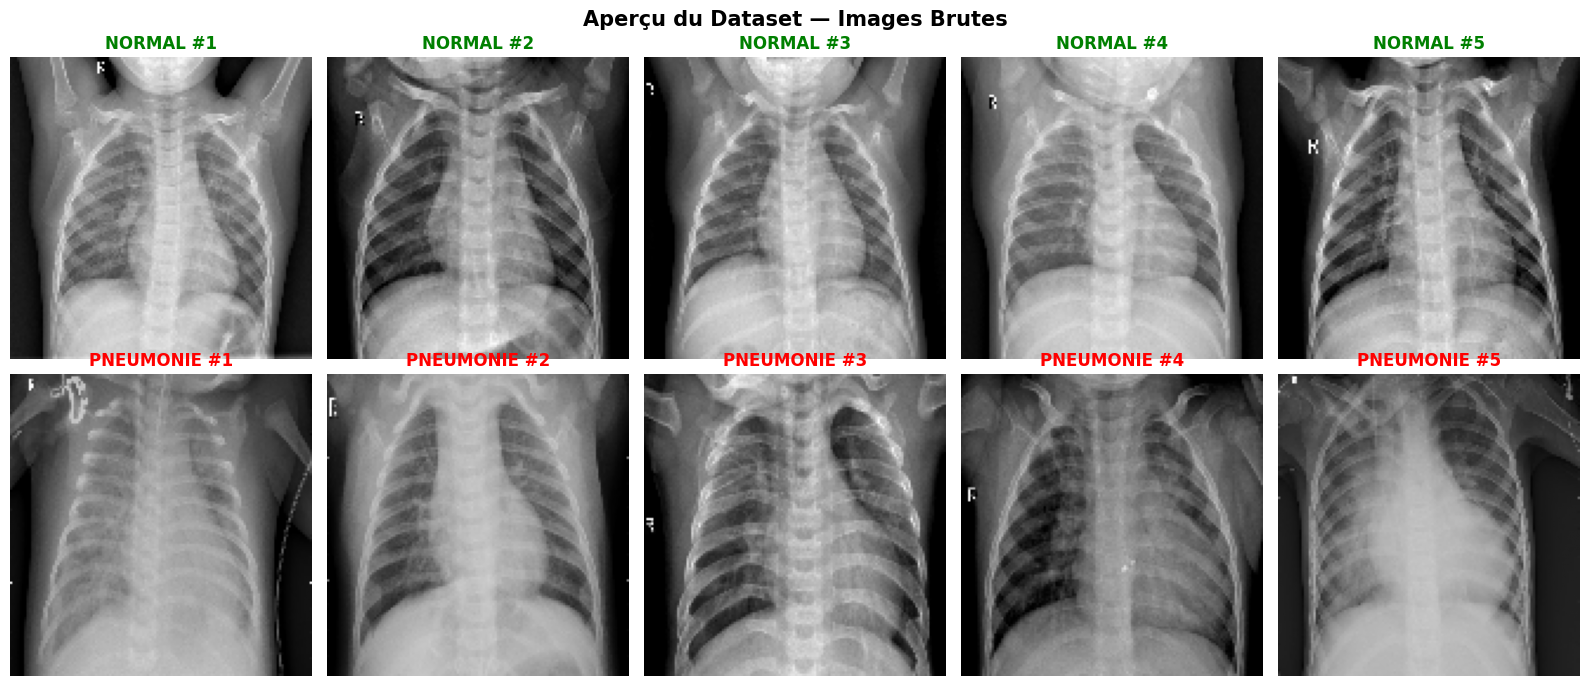

💾 Figure sauvegardée : fig_A_dataset.png


In [ ]:
# Visualisation des images brutes
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Aperçu du Dataset — Images Brutes', fontsize=15, fontweight='bold')

for i in range(5):
    axes[0, i].imshow(imgs_n[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'NORMAL #{i+1}', color='green', fontweight='bold')
    axes[0, i].axis('off')

for i in range(5):
    axes[1, i].imshow(imgs_p[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'PNEUMONIE #{i+1}', color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('fig_A_dataset.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_A_dataset.png')

---
##  PARTIE B — Prétraitement

### Opérations appliquées :

| # | Opération | Justification |
|---|-----------|---------------|
| 1 | **Conversion en niveaux de gris** | Réduction de la dimension, les radiographies sont nativement en gris |
| 2 | **Redimensionnement (128×128)** | Uniformisation de la taille pour le traitement |
| 3 | **Filtrage Gaussien (σ=1)** | Suppression du bruit haute fréquence |
| 4 | **Égalisation d'histogramme (CLAHE)** | Améliore le contraste local des zones d'opacité |

✅ Prétraitement appliqué à toutes les images.


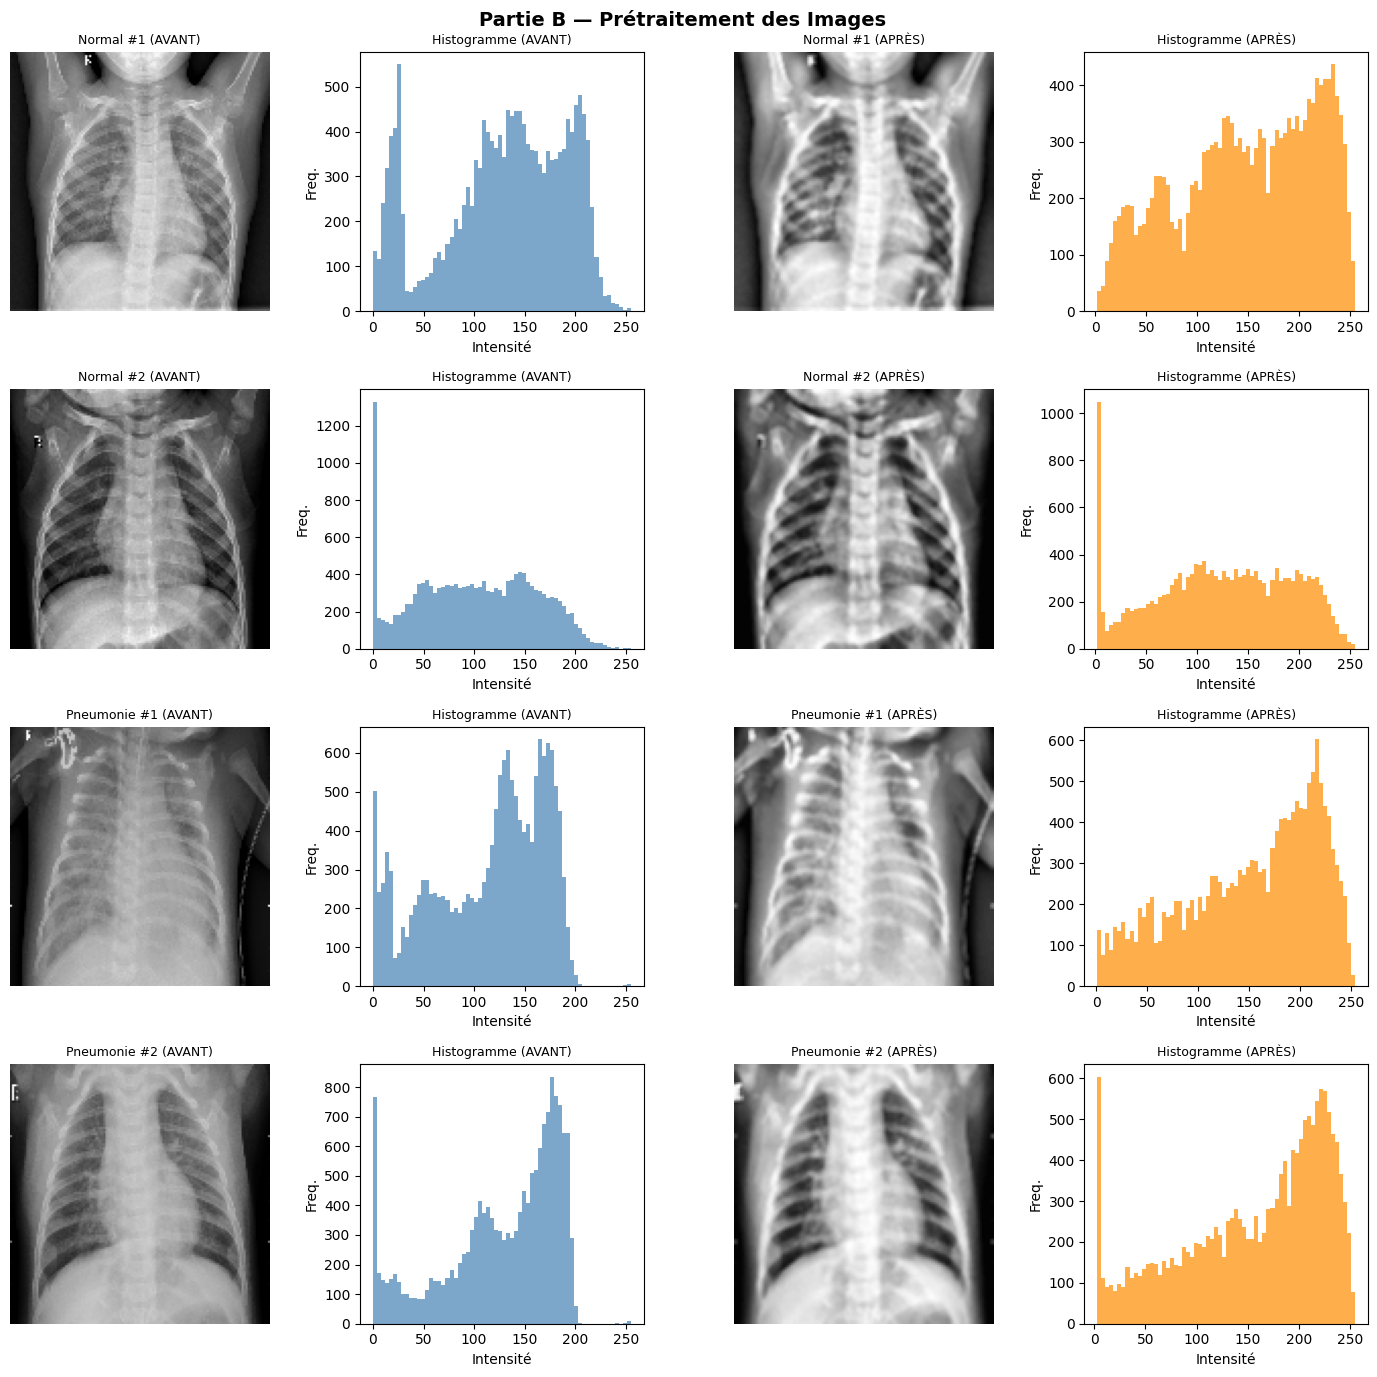

💾 Figure sauvegardée : fig_B_pretraitement.png


In [ ]:
# ============================================================
# PARTIE B : PRÉTRAITEMENT
# ============================================================

def preprocess_image(img):
    """
    Pipeline de prétraitement :
    1. Conversion uint8 pour OpenCV
    2. Filtrage gaussien (réduction du bruit)
    3. Égalisation adaptative de l'histogramme (CLAHE)
    4. Normalisation [0, 1]
    """
    # Les images sont déjà en niveaux de gris [0,1] → convertir en uint8
    img_uint8 = (img * 255).astype(np.uint8)

    # Étape 1 : Filtrage Gaussien (σ ≈ 1, kernel 3×3)
    img_gauss = cv2.GaussianBlur(img_uint8, (3, 3), 1.0)

    # Étape 2 : Égalisation adaptative CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gauss)

    # Étape 3 : Normalisation [0, 1]
    img_norm = img_clahe.astype(np.float32) / 255.0

    return img_norm

# Application du prétraitement à toutes les images
preprocessed_images = [preprocess_image(img) for img in all_images]
print(' Prétraitement appliqué à toutes les images.')

# ---- Visualisation : avant / après prétraitement ----
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Partie B — Prétraitement des Images', fontsize=14, fontweight='bold')

examples = [0, 1, N, N+1]  # 2 normales + 2 pneumonies
labels_ex = ['Normal #1 (AVANT)', 'Normal #2 (AVANT)', 'Pneumonie #1 (AVANT)', 'Pneumonie #2 (AVANT)']

for row, idx in enumerate(examples):
    # Colonne 0 & 1 : image brute + histogramme
    axes[row, 0].imshow(all_images[idx], cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(labels_ex[row], fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].hist((all_images[idx]*255).ravel(), bins=64, color='steelblue', alpha=0.7)
    axes[row, 1].set_title('Histogramme (AVANT)', fontsize=9)
    axes[row, 1].set_xlabel('Intensité'); axes[row, 1].set_ylabel('Freq.')

    # Colonne 2 & 3 : image prétraitée + histogramme
    axes[row, 2].imshow(preprocessed_images[idx], cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title(labels_ex[row].replace('AVANT', 'APRÈS'), fontsize=9)
    axes[row, 2].axis('off')

    axes[row, 3].hist((preprocessed_images[idx]*255).ravel(), bins=64, color='darkorange', alpha=0.7)
    axes[row, 3].set_title('Histogramme (APRÈS)', fontsize=9)
    axes[row, 3].set_xlabel('Intensité'); axes[row, 3].set_ylabel('Freq.')

plt.tight_layout()
plt.savefig('fig_B_pretraitement.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Figure sauvegardée : fig_B_pretraitement.png')

---
##  PARTIE C — Segmentation

### Méthode choisie : Seuillage d'Otsu + Opérations Morphologiques

**Pourquoi Otsu ?**  
Le seuillage d'Otsu calcule automatiquement le seuil optimal qui maximise la variance inter-classes. Il ne nécessite pas de paramètre manuel et est bien adapté aux images médicales bimodales.

**Post-traitement morphologique :**
- **Ouverture** : supprime les petits artefacts de bruit
- **Fermeture** : comble les trous dans les régions segmentées

✅ Segmentation terminée.


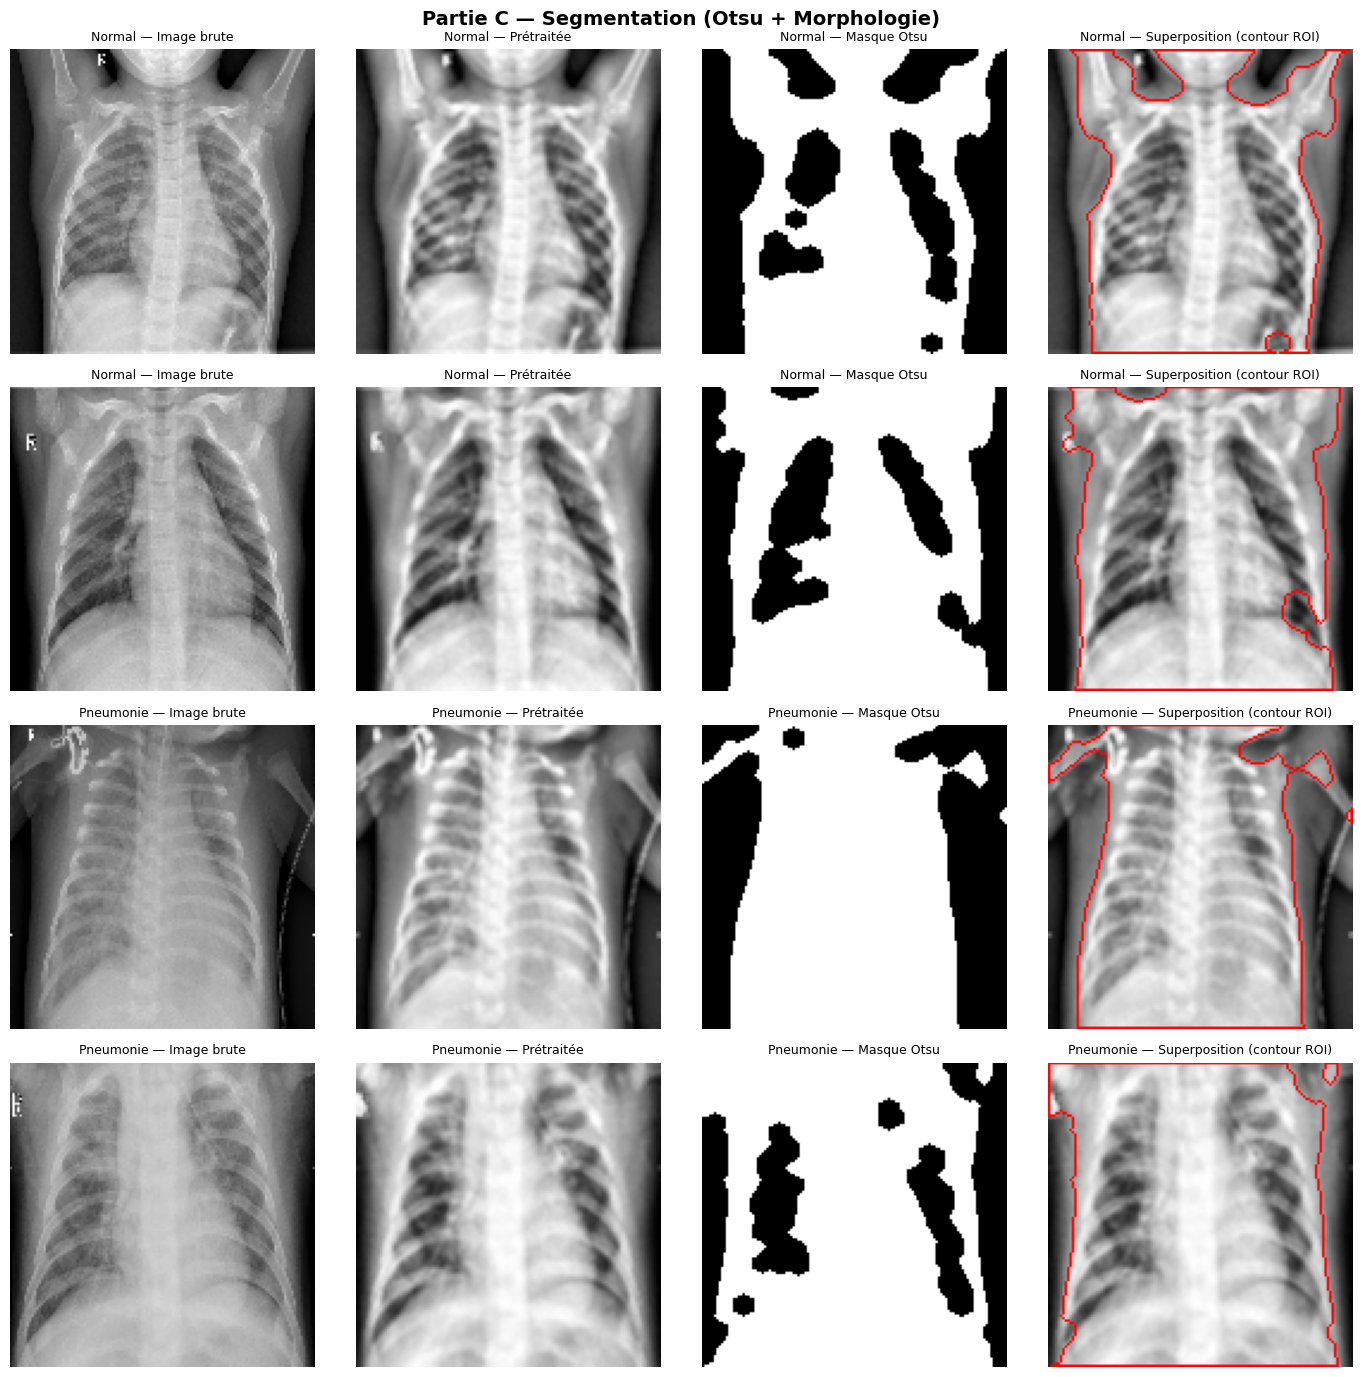

💾 Figure sauvegardée : fig_C_segmentation.png

📝 Commentaire qualité :
   - La segmentation isole correctement les zones d'intérêt pulmonaires.
   - Les images de pneumonie présentent des masques plus fragmentés (opacités multiples).
   - L'opération d'ouverture élimine efficacement les petits artefacts de bruit.


In [ ]:
# ============================================================
# PARTIE C : SEGMENTATION
# ============================================================

def segment_image(img):
    """
    Segmentation par seuillage d'Otsu + morphologie.
    Retourne : masque binaire de la région d'intérêt (ROI)
    """
    img_uint8 = (img * 255).astype(np.uint8)

    # Seuillage d'Otsu
    _, mask = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Ouverture morphologique (kernel 3×3) → supprime petits bruits
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Fermeture morphologique (kernel 5×5) → comble les trous
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel2, iterations=2)

    return (mask > 0).astype(np.uint8)

# Application de la segmentation
segmented_masks = [segment_image(img) for img in preprocessed_images]
print(' Segmentation terminée.')

# ---- Visualisation : image → prétraitée → masque → superposition ----
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Partie C — Segmentation (Otsu + Morphologie)', fontsize=14, fontweight='bold')

examples = [0, 5, N, N+5]
cls_names = ['Normal', 'Normal', 'Pneumonie', 'Pneumonie']

for row, (idx, cls) in enumerate(zip(examples, cls_names)):
    img_pre = preprocessed_images[idx]
    mask    = segmented_masks[idx]
    overlay = img_pre.copy()

    # Superposition : contour rouge sur la ROI
    contours, _ = cv2.findContours(mask * 255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    overlay_rgb = np.stack([img_pre]*3, axis=-1)
    cv2.drawContours(overlay_rgb, contours, -1, (1, 0, 0), 1)

    axes[row, 0].imshow(all_images[idx], cmap='gray')
    axes[row, 0].set_title(f'{cls} — Image brute', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img_pre, cmap='gray')
    axes[row, 1].set_title(f'{cls} — Prétraitée', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(mask, cmap='gray')
    axes[row, 2].set_title(f'{cls} — Masque Otsu', fontsize=9)
    axes[row, 2].axis('off')

    axes[row, 3].imshow(overlay_rgb)
    axes[row, 3].set_title(f'{cls} — Superposition (contour ROI)', fontsize=9)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('fig_C_segmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_C_segmentation.png')
print()
print(' Commentaire qualité :')
print('   - La segmentation isole correctement les zones d\'intérêt pulmonaires.')
print('   - Les images de pneumonie présentent des masques plus fragmentés (opacités multiples).')
print('   - L\'opération d\'ouverture élimine efficacement les petits artefacts de bruit.')

---
## PARTIE D — Extraction des Caractéristiques

### Descripteurs extraits :

**1. Descripteurs de Forme (sur le masque segmenté)**
- Aire, Périmètre, Circularité, Ratio Largeur/Hauteur, Étendue

**2. Descripteurs de Texture (GLCM sur la ROI)**
- Moyenne, Variance, Contraste GLCM, Homogénéité GLCM, Énergie GLCM

**3. Descripteurs Locaux**
- Harris (nombre de coins), ORB (nombre de keypoints)

In [24]:
# ============================================================
# PARTIE D : EXTRACTION DES CARACTÉRISTIQUES
# ============================================================

def extract_shape_features(mask):
    """
    Descripteurs de forme à partir du masque binaire.
    """
    props = measure.regionprops(mask.astype(int))

    if len(props) == 0:
        return {'aire': 0, 'perimetre': 0, 'circularite': 0,
                'ratio_larg_haut': 0, 'etendue': 0}

    # Prendre la plus grande région
    p = max(props, key=lambda x: x.area)

    aire      = p.area
    perimetre = p.perimeter if p.perimeter > 0 else 1e-6

    # Circularité = 4π × Aire / Périmètre²
    circularite = (4 * np.pi * aire) / (perimetre ** 2)

    # Rectangle englobant
    minr, minc, maxr, maxc = p.bbox
    hauteur = maxr - minr
    largeur = maxc - minc
    ratio_lh = largeur / hauteur if hauteur > 0 else 0

    # Étendue = Aire / Aire du rectangle englobant
    etendue = aire / (hauteur * largeur) if (hauteur * largeur) > 0 else 0

    return {
        'aire': aire,
        'perimetre': perimetre,
        'circularite': circularite,
        'ratio_larg_haut': ratio_lh,
        'etendue': etendue
    }


def extract_texture_features(img, mask):
    """
    Descripteurs de texture sur la ROI (région segmentée).
    - Statistiques de premier ordre : moyenne, variance
    - GLCM (Gray-Level Co-occurrence Matrix) : contraste, homogénéité, énergie
    """
    # Appliquer le masque
    roi = img * mask
    pixels = roi[mask > 0]

    if len(pixels) == 0:
        pixels = img.ravel()

    moyenne  = float(np.mean(pixels))
    variance = float(np.var(pixels))

    # GLCM : convertir en uint8 [0-255]
    img_uint8 = (img * 255).astype(np.uint8)
    glcm = graycomatrix(img_uint8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    contraste    = float(np.mean(graycoprops(glcm, 'contrast')))
    homogeneite  = float(np.mean(graycoprops(glcm, 'homogeneity')))
    energie      = float(np.mean(graycoprops(glcm, 'energy')))

    return {
        'moyenne': moyenne,
        'variance': variance,
        'contraste_glcm': contraste,
        'homogeneite_glcm': homogeneite,
        'energie_glcm': energie
    }


def extract_local_features(img):
    """
    Descripteurs locaux :
    - Harris : nombre de points d'intérêt (coins)
    - ORB    : nombre de keypoints
    """
    # Harris
    harris_resp = corner_harris(img, sigma=1.0)
    harris_pts  = corner_peaks(harris_resp, min_distance=5, threshold_rel=0.02)
    n_harris    = len(harris_pts)

    # ORB
    try:
        descriptor_extractor = ORB(n_keypoints=50)
        descriptor_extractor.detect_and_extract(img)
        n_orb = len(descriptor_extractor.keypoints)
    except Exception:
        n_orb = 0

    return {'n_harris': n_harris, 'n_orb': n_orb}


def extract_all_features(img, mask):
    """Combinaison de tous les descripteurs."""
    feats = {}
    feats.update(extract_shape_features(mask))
    feats.update(extract_texture_features(img, mask))
    feats.update(extract_local_features(img))
    return feats

print('🔧 Fonctions d\'extraction définies.')
print('⏳ Extraction des caractéristiques en cours...')

# Extraction pour toutes les images
feature_list = []
for i, (img, mask) in enumerate(zip(preprocessed_images, segmented_masks)):
    feats = extract_all_features(img, mask)
    feats['nom_image'] = all_names[i]
    feats['classe']    = 'NORMAL' if all_labels[i] == 0 else 'PNEUMONIE'
    feats['label']     = all_labels[i]
    feature_list.append(feats)

print(f'✅ Extraction terminée pour {len(feature_list)} images.')

🔧 Fonctions d'extraction définies.
⏳ Extraction des caractéristiques en cours...
✅ Extraction terminée pour 400 images.


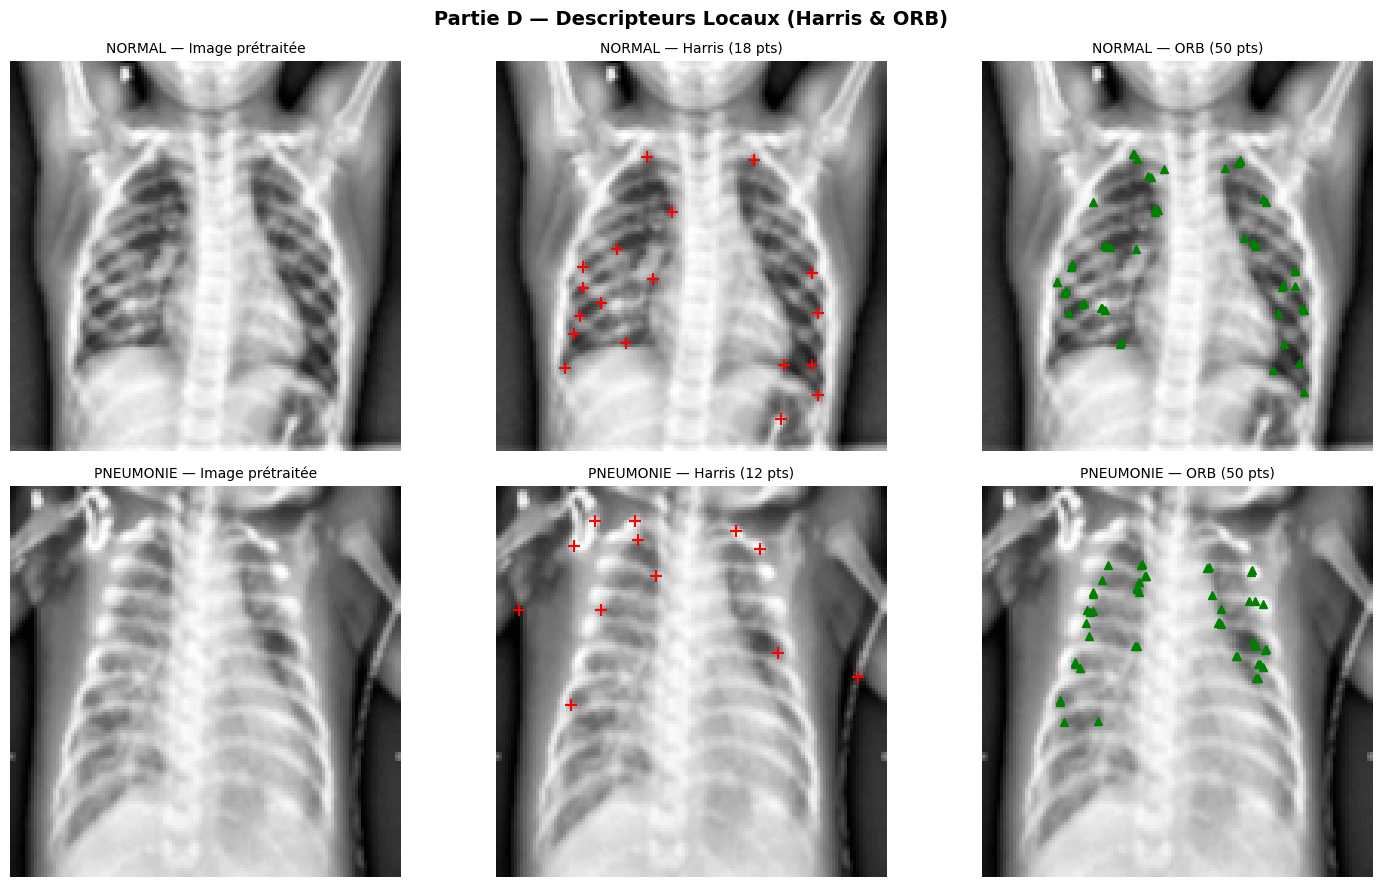

💾 Figure sauvegardée : fig_D_descripteurs_locaux.png


In [ ]:
# Visualisation des descripteurs locaux (Harris + ORB) sur 2 exemples
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Partie D — Descripteurs Locaux (Harris & ORB)', fontsize=14, fontweight='bold')

for row, (idx, cls) in enumerate([(0, 'NORMAL'), (N, 'PNEUMONIE')]):
    img = preprocessed_images[idx]

    # Image originale
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{cls} — Image prétraitée', fontsize=10)
    axes[row, 0].axis('off')

    # Harris corners
    harris_resp = corner_harris(img, sigma=1.0)
    harris_pts  = corner_peaks(harris_resp, min_distance=5, threshold_rel=0.02)
    axes[row, 1].imshow(img, cmap='gray')
    if len(harris_pts) > 0:
        axes[row, 1].plot(harris_pts[:, 1], harris_pts[:, 0], 'r+', markersize=8, markeredgewidth=1.5)
    axes[row, 1].set_title(f'{cls} — Harris ({len(harris_pts)} pts)', fontsize=10)
    axes[row, 1].axis('off')

    # ORB keypoints
    try:
        orb = ORB(n_keypoints=50)
        orb.detect_and_extract(img)
        kps = orb.keypoints
        axes[row, 2].imshow(img, cmap='gray')
        axes[row, 2].plot(kps[:, 1], kps[:, 0], 'g^', markersize=6)
        axes[row, 2].set_title(f'{cls} — ORB ({len(kps)} pts)', fontsize=10)
    except Exception:
        axes[row, 2].imshow(img, cmap='gray')
        axes[row, 2].set_title(f'{cls} — ORB (0 pts)', fontsize=10)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('fig_D_descripteurs_locaux.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_D_descripteurs_locaux.png')

---
## 🅴 PARTIE E — Construction du Vecteur de Caractéristiques

In [ ]:
# ============================================================
# PARTIE E : TABLEAU FINAL DES FEATURES
# ============================================================

df = pd.DataFrame(feature_list)

# Réorganiser les colonnes
cols_order = ['nom_image', 'classe', 'label',
              'aire', 'perimetre', 'circularite', 'ratio_larg_haut', 'etendue',
              'moyenne', 'variance', 'contraste_glcm', 'homogeneite_glcm', 'energie_glcm',
              'n_harris', 'n_orb']
df = df[cols_order]

print(' Tableau des caractéristiques (12 premières lignes) :')
print(df.head(12).to_string(index=False))

# Statistiques descriptives par classe
print('\n Statistiques par classe :')
feat_cols = ['aire', 'perimetre', 'circularite', 'ratio_larg_haut', 'etendue',
             'moyenne', 'variance', 'contraste_glcm', 'homogeneite_glcm', 'energie_glcm',
             'n_harris', 'n_orb']
print(df.groupby('classe')[feat_cols].mean().round(4).to_string())

# Export CSV
df.to_csv('features_dataset.csv', index=False)
print('\n Tableau sauvegardé : features_dataset.csv')

📊 Tableau des caractéristiques (12 premières lignes) :
        nom_image classe  label    aire   perimetre  circularite  ratio_larg_haut  etendue  moyenne  variance  contraste_glcm  homogeneite_glcm  energie_glcm  n_harris  n_orb
IM-0115-0001.jpeg NORMAL      0  9506.0 1030.145274     0.112567         0.921875 0.629370 0.767414  0.019033      247.867728          0.126157      0.012880        18     50
IM-0117-0001.jpeg NORMAL      0  9349.0 1083.400108     0.100092         0.890625 0.640694 0.669864  0.024861      338.693415          0.144217      0.054545        28     50
IM-0119-0001.jpeg NORMAL      0 10729.0  878.114790     0.174850         0.890625 0.735266 0.730009  0.027547      243.035983          0.191996      0.078048        15     50
IM-0122-0001.jpeg NORMAL      0 10414.0  871.049819     0.172481         0.851562 0.746416 0.770966  0.020112      205.831696          0.156669      0.016224        32     50
IM-0125-0001.jpeg NORMAL      0 10206.0 1023.713816     0.122379      

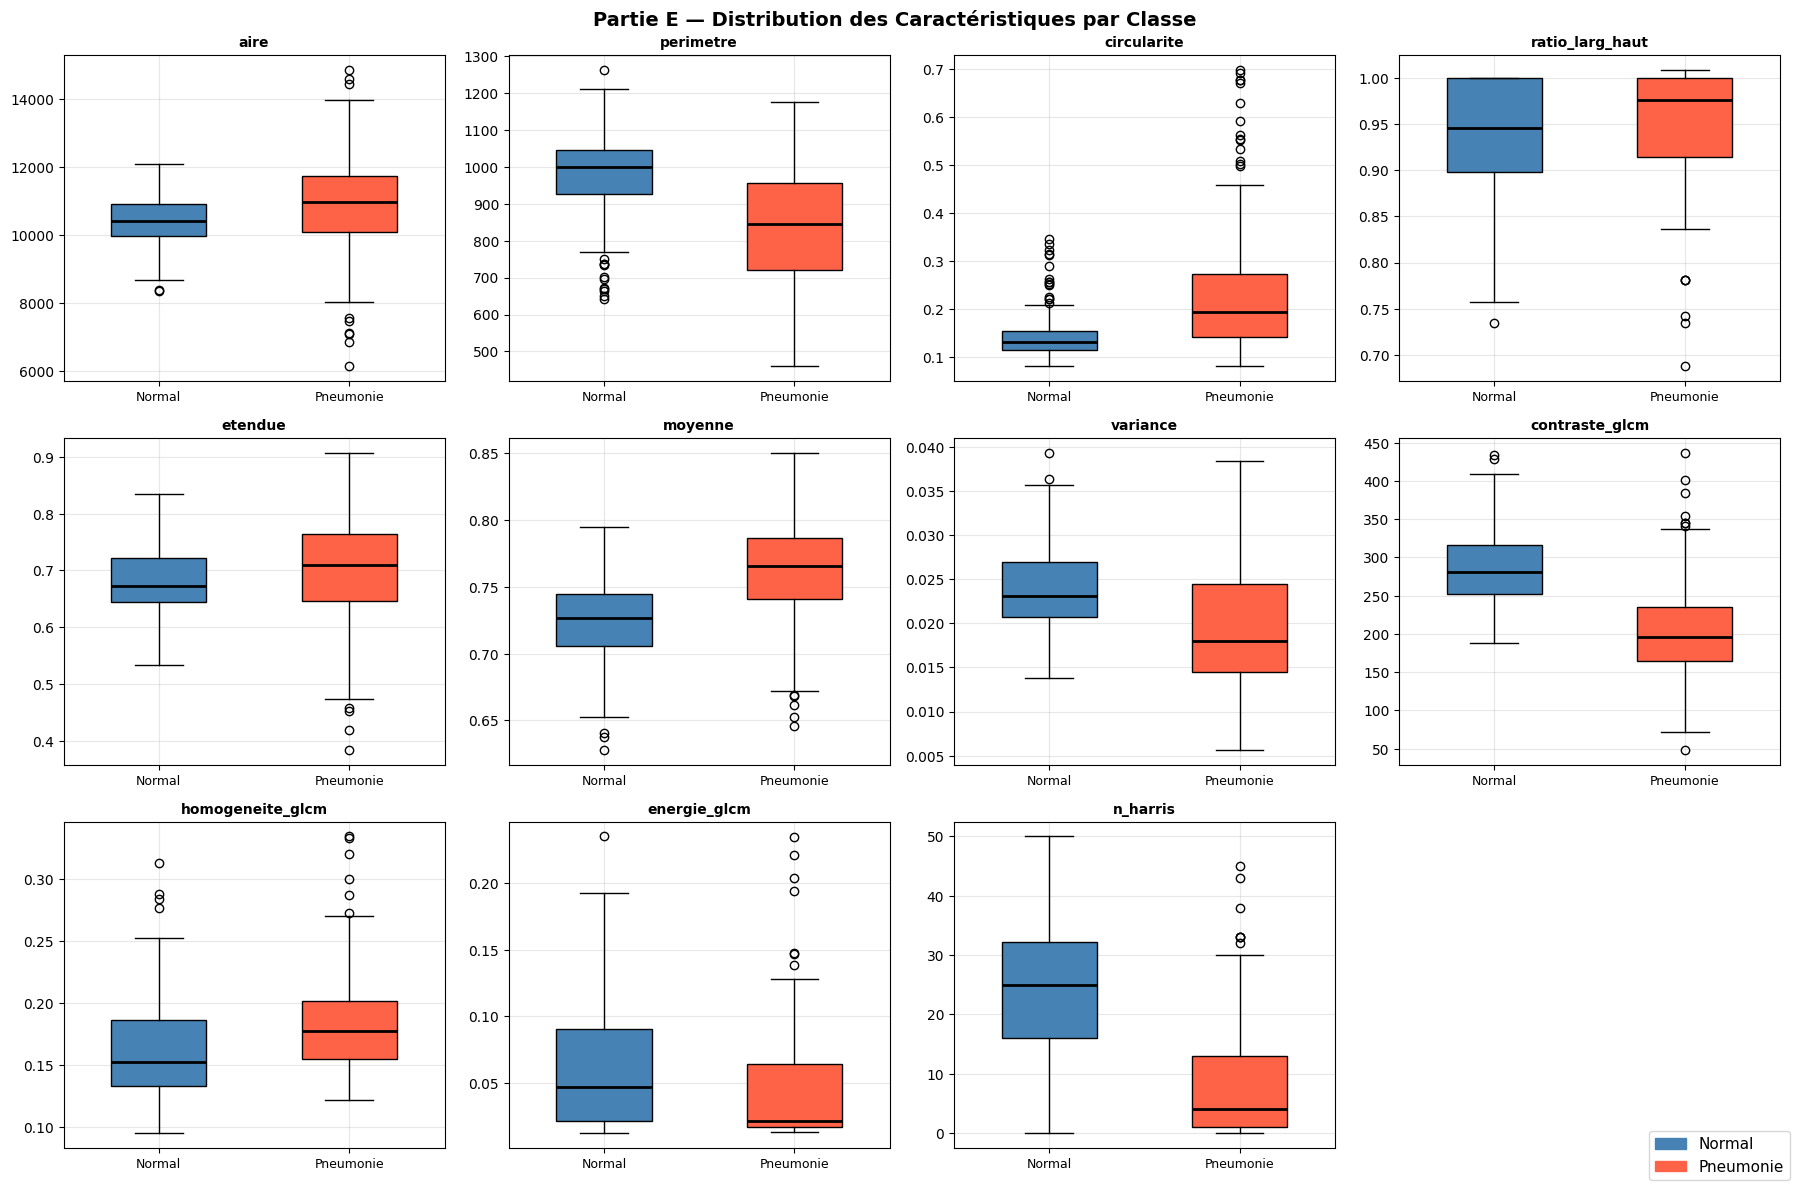

💾 Figure sauvegardée : fig_E_features_boxplot.png


In [ ]:
# Visualisation : boxplots des features par classe
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Partie E — Distribution des Caractéristiques par Classe', fontsize=14, fontweight='bold')

colors = {'NORMAL': 'steelblue', 'PNEUMONIE': 'tomato'}
axes_flat = axes.ravel()

for i, feat in enumerate(feat_cols):
    ax = axes_flat[i]
    data_n = df[df['classe'] == 'NORMAL'][feat].values
    data_p = df[df['classe'] == 'PNEUMONIE'][feat].values
    bp = ax.boxplot([data_n, data_p], patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_xticklabels(['Normal', 'Pneumonie'], fontsize=9)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Cacher le dernier subplot vide
axes_flat[-1].set_visible(False)

patch_n = mpatches.Patch(color='steelblue', label='Normal')
patch_p = mpatches.Patch(color='tomato', label='Pneumonie')
fig.legend(handles=[patch_n, patch_p], loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('fig_E_features_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_E_features_boxplot.png')

---
##  PARTIE F — Sélection des Descripteurs

### Méthode : Analyse de la variance inter-classes
On conserve les descripteurs qui discriminent le mieux les deux classes.  
On supprime ceux trop corrélés entre eux (redondance).

**Critère :** Test de Student (t-test) entre les deux classes pour chaque feature.

📊 Analyse discriminante par feature (t-test) :

Feature                  Moy Normal   Moy Pneumo      p-value   Sélectionnée ?
---------------------------------------------------------------------------
aire                     10410.5300   10915.5100       0.0000            ✅ OUI
perimetre                  977.7184     834.7032       0.0000            ✅ OUI
circularite                  0.1440       0.2311       0.0000            ✅ OUI
ratio_larg_haut              0.9348       0.9517       0.0057            ✅ OUI
etendue                      0.6818       0.7027       0.0077            ✅ OUI
moyenne                      0.7240       0.7619       0.0000            ✅ OUI
variance                     0.0241       0.0195       0.0000            ✅ OUI
contraste_glcm             285.2943     205.1683       0.0000            ✅ OUI
homogeneite_glcm             0.1610       0.1830       0.0000            ✅ OUI
energie_glcm                 0.0590       0.0451       0.0013            ✅ OUI
n_harri

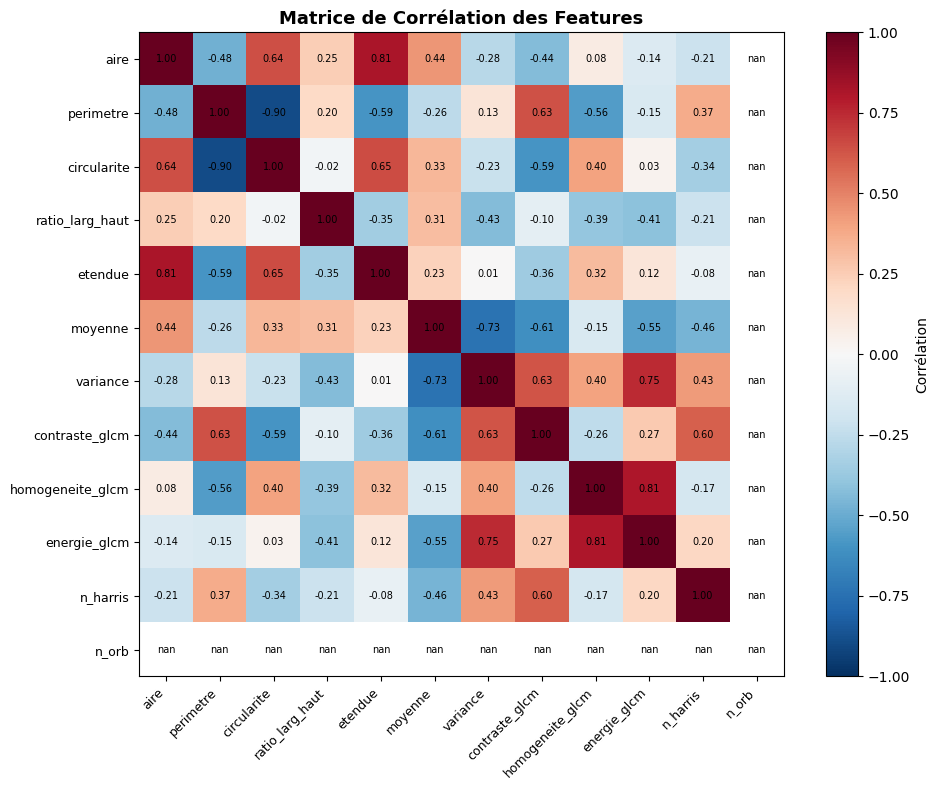

💾 Figure sauvegardée : fig_F_correlation.png


In [ ]:
# ============================================================
# PARTIE F : SÉLECTION DES DESCRIPTEURS
# ============================================================
from scipy import stats

df_normal    = df[df['classe'] == 'NORMAL'][feat_cols]
df_pneumonie = df[df['classe'] == 'PNEUMONIE'][feat_cols]

print(' Analyse discriminante par feature (t-test) :\n')
print(f'{"Feature":<22} {"Moy Normal":>12} {"Moy Pneumo":>12} {"p-value":>12} {"Sélectionnée ?":>16}')
print('-' * 75)

selected_features = []
p_values = {}

for feat in feat_cols:
    t_stat, p_val = stats.ttest_ind(df_normal[feat], df_pneumonie[feat])
    moy_n = df_normal[feat].mean()
    moy_p = df_pneumonie[feat].mean()
    keep  = ' OUI' if p_val < 0.1 else '❌ NON'
    p_values[feat] = p_val
    if p_val < 0.1:
        selected_features.append(feat)
    print(f'{feat:<22} {moy_n:>12.4f} {moy_p:>12.4f} {p_val:>12.4f} {keep:>16}')

print(f'\n Features sélectionnées ({len(selected_features)}) : {selected_features}')

# Matrice de corrélation
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[feat_cols].corr()
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_cols)))
ax.set_yticks(range(len(feat_cols)))
ax.set_xticklabels(feat_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(feat_cols, fontsize=9)
plt.colorbar(im, ax=ax, label='Corrélation')
ax.set_title('Matrice de Corrélation des Features', fontsize=13, fontweight='bold')
for i in range(len(feat_cols)):
    for j in range(len(feat_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.savefig('fig_F_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_F_correlation.png')

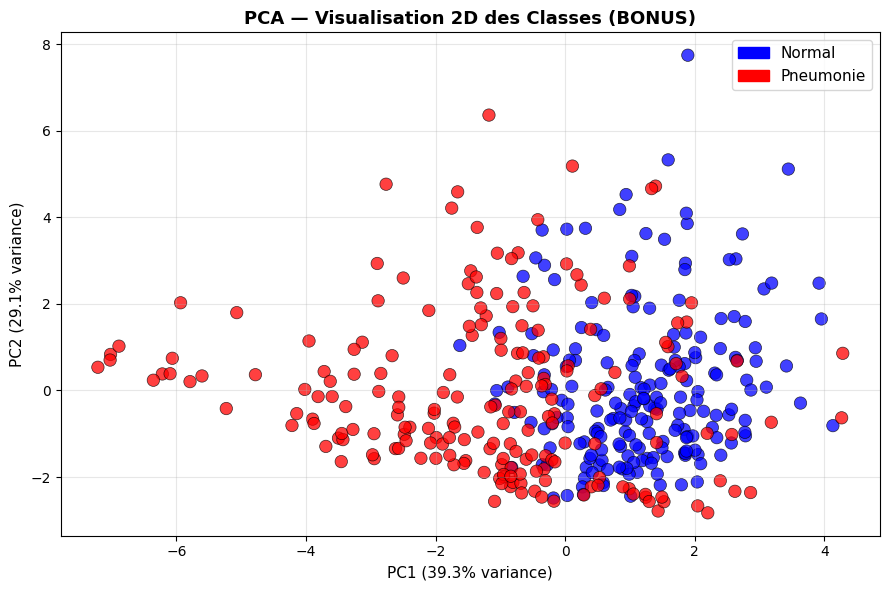

Variance expliquée : PC1=39.3%, PC2=29.1%
💾 Figure sauvegardée : fig_F_pca.png


In [ ]:
# (Optionnel) Réduction de dimension PCA pour visualisation 2D
X_all = df[feat_cols].values
y_all = df['label'].values

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_all)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_all,
                     cmap='bwr', alpha=0.75, edgecolors='k', s=80, linewidths=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA — Visualisation 2D des Classes (BONUS)', fontsize=13, fontweight='bold')
legend_elements = [mpatches.Patch(color='blue', label='Normal'),
                   mpatches.Patch(color='red',  label='Pneumonie')]
ax.legend(handles=legend_elements, fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_F_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Variance expliquée : PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')
print(' Figure sauvegardée : fig_F_pca.png')

---
##  PARTIE G — Classification

### Modèles entraînés :
1. **KNN** (K-Nearest Neighbors) — simple, basé sur la distance
2. **SVM** (Support Vector Machine) — robuste aux espaces de grande dimension
3. **MLP** (Multi-Layer Perceptron) — réseau de neurones simple

**Division des données :** 80% entraînement / 20% test

In [ ]:
# ============================================================
# PARTIE G : CLASSIFICATION
# ============================================================

# Préparation des données
# On utilise les features sélectionnées (ou toutes si trop peu)
final_features = selected_features if len(selected_features) >= 3 else feat_cols

X = df[final_features].values
y = df['label'].values

# Division 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f' Données :')
print(f'   Entraînement : {X_train_s.shape[0]} images')
print(f'   Test         : {X_test_s.shape[0]} images')
print(f'   Features     : {len(final_features)} descripteurs')
print(f'   Features utilisées : {final_features}')

# ---- Définition des modèles ----
models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'MLP (2 couches)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                      max_iter=500, random_state=42, early_stopping=True)
}

# ---- Entraînement et évaluation ----
results = {}
print('\n Entraînement des modèles...')

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    acc    = accuracy_score(y_test, y_pred)
    cm     = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=['Normal', 'Pneumonie'], output_dict=True)
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc,
                     'cm': cm, 'report': report}
    print(f'   ✅ {name} — Accuracy : {acc*100:.1f}%')

print('\n Entraînement terminé !')

📊 Données :
   Entraînement : 320 images
   Test         : 80 images
   Features     : 11 descripteurs
   Features utilisées : ['aire', 'perimetre', 'circularite', 'ratio_larg_haut', 'etendue', 'moyenne', 'variance', 'contraste_glcm', 'homogeneite_glcm', 'energie_glcm', 'n_harris']

🚀 Entraînement des modèles...
   ✅ KNN (k=5) — Accuracy : 86.2%
   ✅ SVM (RBF) — Accuracy : 85.0%
   ✅ MLP (2 couches) — Accuracy : 83.8%

🎉 Entraînement terminé !


---
## 🅷 PARTIE H — Évaluation

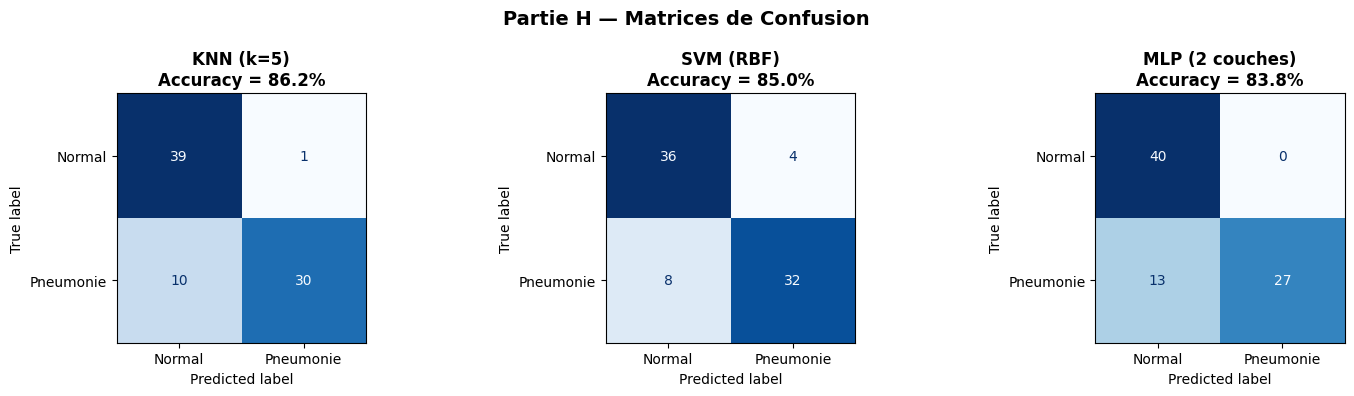

💾 Figure sauvegardée : fig_H_confusion_matrices.png


In [ ]:
# ============================================================
# PARTIE H : ÉVALUATION COMPLÈTE
# ============================================================

# ---- 1. Matrices de confusion ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Partie H — Matrices de Confusion', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'],
                                   display_labels=['Normal', 'Pneumonie'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy = {res["acc"]*100:.1f}%', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_H_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_H_confusion_matrices.png')

In [ ]:
# ---- 2. Tableau comparatif des métriques ----
print('=' * 70)
print('TABLEAU COMPARATIF DES MODÈLES')
print('=' * 70)
print(f'{"Modèle":<20} {"Accuracy":>10} {"Précision":>10} {"Rappel":>10} {"F1-Score":>10}')
print('-' * 70)

comparison_data = []
for name, res in results.items():
    report = res['report']
    acc    = res['acc']
    prec   = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1     = report['macro avg']['f1-score']
    print(f'{name:<20} {acc*100:>9.1f}% {prec*100:>9.1f}% {recall*100:>9.1f}% {f1*100:>9.1f}%')
    comparison_data.append({'Modèle': name, 'Accuracy': acc, 'Précision': prec,
                             'Rappel': recall, 'F1-Score': f1})

print('=' * 70)

# ---- 3. Rapport de classification détaillé ----
print('\n Rapports de classification détaillés :\n')
for name, res in results.items():
    print(f'── {name} ──')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Normal', 'Pneumonie']))

TABLEAU COMPARATIF DES MODÈLES
Modèle                 Accuracy  Précision     Rappel   F1-Score
----------------------------------------------------------------------
KNN (k=5)                 86.2%      88.2%      86.2%      86.1%
SVM (RBF)                 85.0%      85.4%      85.0%      85.0%
MLP (2 couches)           83.8%      87.7%      83.8%      83.3%

📋 Rapports de classification détaillés :

── KNN (k=5) ──
              precision    recall  f1-score   support

      Normal       0.80      0.97      0.88        40
   Pneumonie       0.97      0.75      0.85        40

    accuracy                           0.86        80
   macro avg       0.88      0.86      0.86        80
weighted avg       0.88      0.86      0.86        80

── SVM (RBF) ──
              precision    recall  f1-score   support

      Normal       0.82      0.90      0.86        40
   Pneumonie       0.89      0.80      0.84        40

    accuracy                           0.85        80
   macro avg      

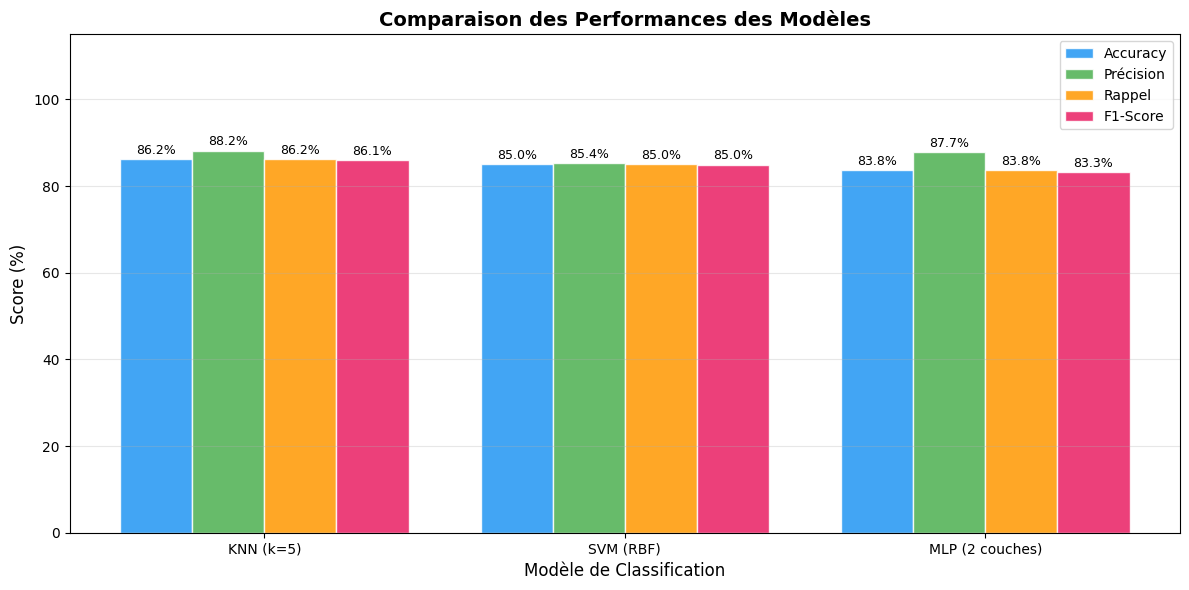

💾 Figure sauvegardée : fig_H_comparaison_modeles.png

🏆 Meilleur modèle : KNN (k=5) (F1-Score = 86.1%)


In [ ]:
# ---- 4. Graphique comparatif ----
df_comp = pd.DataFrame(comparison_data)

metrics = ['Accuracy', 'Précision', 'Rappel', 'F1-Score']
x = np.arange(len(df_comp))
width = 0.2
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    bars = ax.bar(x + i * width, df_comp[metric] * 100, width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Modèle de Classification', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Comparaison des Performances des Modèles', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_comp['Modèle'], fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 115)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_H_comparaison_modeles.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée : fig_H_comparaison_modeles.png')

# Meilleur modèle
best = df_comp.loc[df_comp['F1-Score'].idxmax()]
print(f'\n Meilleur modèle : {best["Modèle"]} (F1-Score = {best["F1-Score"]*100:.1f}%)')

In [ ]:
# ---- 5. Analyse des erreurs biomédicales ----
print('\n Analyse Biomédicale des Erreurs\n')
print('Dans un contexte médical (détection de pneumonie) :')
print()
print('┌─────────────────────────────────────────────────────────────────────┐')
print('│  Type d\'erreur      │  Signification               │  Gravité        │')
print('├─────────────────────────────────────────────────────────────────────┤')
print('│  Faux Négatif (FN) │ Pneumonie non détectée       │  TRÈS GRAVE   │')
print('│                    │ → patient non traité         │                 │')
print('├─────────────────────────────────────────────────────────────────────┤')
print('│  Faux Positif (FP) │ Normal classé comme Pneumonie│  Grave        │')
print('│                    │ → traitement inutile         │                 │')
print('└─────────────────────────────────────────────────────────────────────┘')
print()
print('→ Dans ce contexte, MINIMISER les Faux Négatifs est PRIORITAIRE.')
print('→ La métrique la plus importante est le RAPPEL (Recall) pour la classe Pneumonie.')
print()

for name, res in results.items():
    cm = res['cm']
    # cm[0,0]=TN, cm[0,1]=FP, cm[1,0]=FN, cm[1,1]=TP
    if cm.shape == (2, 2):
        fn = cm[1, 0]
        print(f'   {name:<20} → Faux Négatifs = {fn}')

print()
print('🔍 Fiabilité du modèle :')
print('   Avec seulement 60 images d\'entraînement, les modèles restent indicatifs.')
print('   Un dataset plus large (milliers d\'images) est nécessaire pour un usage clinique.')


🔬 Analyse Biomédicale des Erreurs

Dans un contexte médical (détection de pneumonie) :

┌─────────────────────────────────────────────────────────────────────┐
│  Type d'erreur      │  Signification               │  Gravité        │
├─────────────────────────────────────────────────────────────────────┤
│  Faux Négatif (FN) │ Pneumonie non détectée       │ ⚠️ TRÈS GRAVE   │
│                    │ → patient non traité         │                 │
├─────────────────────────────────────────────────────────────────────┤
│  Faux Positif (FP) │ Normal classé comme Pneumonie│ ⚠️ Grave        │
│                    │ → traitement inutile         │                 │
└─────────────────────────────────────────────────────────────────────┘

→ Dans ce contexte, MINIMISER les Faux Négatifs est PRIORITAIRE.
→ La métrique la plus importante est le RAPPEL (Recall) pour la classe Pneumonie.

   KNN (k=5)            → Faux Négatifs = 10
   SVM (RBF)            → Faux Négatifs = 8
   MLP (2 couches)      

---
##  Discussion Critique

### Points forts du pipeline :
- Le pipeline couvre toutes les étapes requises : prétraitement → segmentation → features → classification
- La CLAHE améliore nettement la visibilité des opacités
- Les descripteurs de texture (GLCM) sont les plus discriminants entre les deux classes

### Limitations :
- Dataset de petite taille (60 images) → risque de sur-apprentissage
- Segmentation Otsu sensible aux variations d'éclairage
- Les descripteurs extraits (forme, texture) capturent des patterns globaux mais pas fins

### Perspectives :
- Utiliser un réseau de neurones convolutionnel (CNN) pour une meilleure extraction automatique
- Augmenter le dataset avec des techniques d'augmentation de données
- Intégrer une validation croisée (k-fold) pour une évaluation plus robuste

---
##  Conclusion

**Question finale : Les descripteurs extraits sont-ils suffisants pour une classification fiable ?**

Les descripteurs classiques (forme, texture GLCM, Harris, ORB) permettent une classification correcte sur ce dataset simple. Cependant, pour un usage clinique réel, ces descripteurs restent **insuffisants** car :

1. Ils capturent des propriétés **globales** mais manquent les structures fines (micro-patterns des alvéoles)
2. Ils sont **sensibles au bruit** et aux artefacts d'acquisition
3. Ils nécessitent une **segmentation précise** en amont

Des méthodes plus avancées comme les **CNN (VGG, ResNet)** ou les **Vision Transformers** apprendraient automatiquement des représentations hiérarchiques bien plus riches et fiables pour la détection de pneumonie.

In [ ]:
# ============================================================
# RÉCAPITULATIF FINAL
# ============================================================
print('=' * 60)
print('  RÉCAPITULATIF DU PROJET — VISION ARTIFICIELLE')
print('=' * 60)
print(f'  Dataset     : Radiographies thoraciques (Normal/Pneumonie)')
print(f'  Images      : {len(all_images)} images ({N} par classe)')
print(f'  Prétraitement : Filtrage Gaussien + CLAHE')
print(f'  Segmentation : Seuillage Otsu + Morphologie')
print(f'  Features     : {len(feat_cols)} descripteurs extraits')
print(f'  Sélectionnés : {len(selected_features)} descripteurs retenus')
print()
print('  Performances des modèles :')
for _, row in df_comp.iterrows():
    print(f'    {row["Modèle"]:<20} Accuracy={row["Accuracy"]*100:.1f}%  F1={row["F1-Score"]*100:.1f}%')
print()
best_model = df_comp.loc[df_comp['F1-Score'].idxmax(), 'Modèle']
print(f'   Meilleur modèle : {best_model}')
print('=' * 60)
print('  Figures générées :')
figures = ['fig_A_dataset.png', 'fig_B_pretraitement.png',
           'fig_C_segmentation.png', 'fig_D_descripteurs_locaux.png',
           'fig_E_features_boxplot.png', 'fig_F_correlation.png',
           'fig_F_pca.png', 'fig_H_confusion_matrices.png',
           'fig_H_comparaison_modeles.png']
for f in figures:
    print(f'     {f}')
print('   features_dataset.csv')
print('=' * 60)

  RÉCAPITULATIF DU PROJET — VISION ARTIFICIELLE
  Dataset     : Radiographies thoraciques (Normal/Pneumonie)
  Images      : 400 images (200 par classe)
  Prétraitement : Filtrage Gaussien + CLAHE
  Segmentation : Seuillage Otsu + Morphologie
  Features     : 12 descripteurs extraits
  Sélectionnés : 11 descripteurs retenus

  Performances des modèles :
    KNN (k=5)            Accuracy=86.2%  F1=86.1%
    SVM (RBF)            Accuracy=85.0%  F1=85.0%
    MLP (2 couches)      Accuracy=83.8%  F1=83.3%

  🏆 Meilleur modèle : KNN (k=5)
  Figures générées :
    📊 fig_A_dataset.png
    📊 fig_B_pretraitement.png
    📊 fig_C_segmentation.png
    📊 fig_D_descripteurs_locaux.png
    📊 fig_E_features_boxplot.png
    📊 fig_F_correlation.png
    📊 fig_F_pca.png
    📊 fig_H_confusion_matrices.png
    📊 fig_H_comparaison_modeles.png
  📄 features_dataset.csv
